![](../../../images/header.png)

# DESI Light Path
<h6>Authors : James Rohlf and Claude Opus 4.7</h6>
<h6>Last Updated : May 10, 2026</h6>

desi_light_path.py
==================
Animated diagram of the full DESI light path, from galaxy to CCD.

Stages animated in sequence:
  0. Galaxy emits light
  1. Mayall 4-metre telescope collects and focuses
  2. Focal plane — 5000 fiber positioners
  3. Optical fiber routes light to spectrograph room
  4. Collimator makes parallel beam
  5. Dichroic 1 reflects blue (360–593 nm), transmits red + NIR
  6. Dichroic 2 reflects red (566–772 nm), transmits NIR (747–980 nm)
  7. VPH grating disperses blue arm → CCD B
  8. VPH grating disperses red arm → CCD R
  9. VPH grating disperses NIR arm → CCD N
 10. All three CCDs illuminated simultaneously

Controls:
  SPACE  — play / pause
  R      — restart
  LEFT / RIGHT arrows — step one stage back / forward

Saves:
  desi_light_path.gif   — 150-frame animated GIF (auto-saved)
  desi_light_path.png   — single-frame summary poster

Usage:
    python desi_light_path.py

Requirements:
    numpy, matplotlib
    (Optional: Pillow for GIF export — pip install Pillow)

By the end of this notebook, you should be able to:

- Trace light from a galaxy through the Mayall telescope, fibers, collimator, dichroics, and VPH gratings onto the blue, red, and NIR CCDs
- Recognize the role of each optical element in delivering a calibrated, dispersed spectrum

## Preferred Backgrounds
While not necessary, having knowledge about the following topics will be helpful in completing this notebook on time:

- TODO

**Run the cell below to load the basic Python packages we need to run this notebook.**

In [ ]:
# --- Jupyter prep ---
# Inline interactive figures via ipympl. If `ipympl` isn't
# installed, swap this for `%matplotlib tk` (separate window,
# needs tkinter) or `%matplotlib inline` (static images only,
# Slider / Button widgets won't be interactive).
%matplotlib widget

# Stop argparse / sys.argv checks from picking up the kernel launch args
# (e.g. `-f /.../kernel-xxxx.json`), which would otherwise make argparse
# raise SystemExit inside the notebook.
import sys
sys.argv = sys.argv[:1]

# Notebooks don't define `__file__`, but several of these scripts use it
# to locate an output directory for saved PNGs / CSVs / GIFs. Define it
# here so `os.path.dirname(os.path.abspath(__file__))` resolves to the
# directory this notebook lives in.
import os
__file__ = os.path.join(os.getcwd(), "notebook.py")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.animation import FuncAnimation
from matplotlib.patches import FancyArrowPatch, Arc
import matplotlib.transforms as transforms


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  LAYOUT  (all coordinates in axes units 0–1 normalised to figure)
#  We use a single large Axes with no ticks, and place everything by hand.
# ─────────────────────────────────────────────────────────────────────────────

FIG_W, FIG_H = 16, 10
BG  = '#07070f'
FG  = '#ccccdd'

BLUE_COL  = '#6699ff'
RED_COL   = '#ff7733'
NIR_COL   = '#aa1100'       # dark red (near-infrared just past visible)
WHITE_COL = '#ffffff'       # actually white
DIM_ALPHA = 0.18

# Stage durations in animation frames (at 25 fps → seconds = frames/25)
STAGE_FRAMES = [30, 35, 35, 45, 30, 40, 40, 40, 40, 40, 50]
STAGE_LABELS = [
    "Galaxy emits light across the visible spectrum",
    "Mayall 4-m telescope (Kitt Peak) collects and focuses light",
    "Focal plane: robotic fiber positioner captures the galaxy",
    "107-μm optical fiber routes light 50 m to spectrograph",
    "Collimator lens produces a parallel beam",
    "Dichroic 1 reflects blue (360–593 nm), transmits red+NIR",
    "Dichroic 2 reflects red (566–772 nm), transmits NIR (747–980 nm)",
    "VPH grating disperses blue arm — wavelength → CCD pixel",
    "VPH grating disperses red arm — [OII] 746 nm lands here",
    "VPH grating disperses NIR arm — Hα at high-z lands here",
    "All three CCDs record 500 fiber spectra simultaneously",
]
TOTAL_FRAMES = sum(STAGE_FRAMES)

# ─────────────────────────────────────────────────────────────────────────────
#  COMPONENT POSITIONS  (x, y in data coords;  axes xlim 0–16, ylim 0–10)
# ─────────────────────────────────────────────────────────────────────────────

# Galaxy — upper-right area (canvas is 16 × 10).  Kept a bit inside the
# canvas so the glow pulse and spiral arms don't get clipped.
GAL_XY   = (14.85, 9.15)
GAL_R    = 0.22
GAL_ARM_SCALE = 0.07

# Telescope primary mirror — tilted toward (but not directly at) the galaxy
TEL_XY   = (11.0, 5.5)
TEL_W, TEL_H = 2.0, 0.9
# angle of optical axis (from vertical), with a small CCW rotation offset
_dx, _dy = GAL_XY[0] - TEL_XY[0], GAL_XY[1] - TEL_XY[1]
TEL_TILT_CCW_DEG = 7                     # rotate telescope+FP ~7° CCW
TEL_TILT = np.arctan2(_dx, _dy) - np.radians(TEL_TILT_CCW_DEG)
_ax_x = np.sin(TEL_TILT); _ax_y = np.cos(TEL_TILT)   # unit vector along axis
_perp_x = _ax_y; _perp_y = -_ax_x                    # perpendicular to axis

# Focal plane (prime focus) — along optical axis, between mirror and galaxy
FP_DIST  = 2.6
FP_XY    = (TEL_XY[0] + _ax_x * FP_DIST, TEL_XY[1] + _ax_y * FP_DIST)
FP_R     = 0.5                             # radius of the little DESI disc
FP_TILT_SCALE = 0.40                       # 3D foreshortening (minor/major axis)

# Corrector lens — between the primary mirror and the focal plane, on the
# optical axis.  DESI's prime-focus corrector re-shapes the wavefront just
# before it lands on the fiber-positioner plate; we draw it as a thin lens
# perpendicular to the axis and bend the animated ray as it passes through.
CORR_FRAC  = 0.68                          # fraction of FP_DIST from mirror
CORR_XY    = (TEL_XY[0] + _ax_x * FP_DIST * CORR_FRAC,
              TEL_XY[1] + _ax_y * FP_DIST * CORR_FRAC)
CORR_HALFW = FP_R                          # same diameter as the focal plane
CORR_HALFT = 0.07                          # thickness along axis

# Fiber run (bezier control point) — now starts near the focal plane
# Spectrograph box
SPEC_BOX = (1.0, 1.2, 8.0, 8.0)  # x, y, w, h

# HORIZONTAL optical layout (light travels LEFT along y = OPTICAL_Y):
#   fiber → V-groove → collimator → D1 → D2 → red CCD
#   D1 reflects blue DOWN to blue arm
#   D2 reflects red DOWN to red arm
OPTICAL_Y = 6.6                     # spectrograph raised ~0.6 so the fiber
                                    # cable doesn't brush past the telescope

# V-groove block (right end, fiber enters from its RIGHT face)
VG_W, VG_H = 0.7, 1.0
VG_XY    = (8.4, OPTICAL_Y)
# Collimator lens — SAME width as V-groove; small gap between them
COL_W, COL_H = VG_W, VG_H
COL_XY   = (VG_XY[0] - VG_W - 0.35, OPTICAL_Y)   # 0.35-unit gap between the two

# 11 horizontal grooves inside the V-groove block — middle groove sits
# on the optical axis so the fibre → D1 beam is one straight horizontal line.
N_GROOVES = 11
GROOVE_YS = np.linspace(VG_XY[1] - VG_H/2 + 0.08,
                        VG_XY[1] + VG_H/2 - 0.08, N_GROOVES)
FIBER_GROOVE_IDX = N_GROOVES // 2                # middle groove (at OPTICAL_Y)
FIB_GROOVE_Y = GROOVE_YS[FIBER_GROOVE_IDX]

# Fiber run (bezier) — starts at the EDGE of the tilted DESI disc, ends
# aligned horizontally with the V-groove at the chosen groove height.
# Pick the rim point of the tilted ellipse in the direction of the V-groove.
_vg_right = VG_XY[0] + VG_W / 2
_vdx = _vg_right - FP_XY[0]
_vdy = FIB_GROOVE_Y - FP_XY[1]
# project V-groove direction into local (perp, ax) frame
_lp = _vdx * _perp_x + _vdy * _perp_y
_la = _vdx * _ax_x   + _vdy * _ax_y
# parametric angle on the tilted ellipse pointing that way; nudged so the
# fiber exits a little higher on the rim and doesn't clip the corrector lens
_t = np.arctan2(_la / FP_TILT_SCALE, _lp) - 0.45
_rx = FP_R * np.cos(_t)
_ry = FP_R * FP_TILT_SCALE * np.sin(_t)
FIB_EDGE_XY = (FP_XY[0] + _rx * _perp_x + _ry * _ax_x,
               FP_XY[1] + _rx * _perp_y + _ry * _ax_y)

FIB_P0   = FIB_EDGE_XY
FIB_P1   = (FIB_EDGE_XY[0] - 1.4, FIB_EDGE_XY[1] - 0.5)
FIB_P2   = (_vg_right + 1.2, FIB_GROOVE_Y)   # horizontal approach to V-groove
FIB_P3   = (_vg_right, FIB_GROOVE_Y)

# Dichroic 1 (blue split) — space between collimator and D1
D1_XY    = (COL_XY[0] - COL_W/2 - 1.05, OPTICAL_Y)
# Dichroic 2 (red/NIR split) — further left of D1, same y
D2_XY    = (D1_XY[0] - 1.55, OPTICAL_Y)

# --- arm geometry: equal grating→CCD distance for all three arms ---
ARM_LEN = 1.4                       # grating → CCD centre distance
# Blue arm — light reflects DOWN off D1  (gratings shifted up with OPTICAL_Y)
GB_XY    = (D1_XY[0], OPTICAL_Y - 2.0)
CB_XY    = (D1_XY[0], GB_XY[1] - ARM_LEN)
# Red arm — light reflects DOWN off D2
GR_XY    = (D2_XY[0], OPTICAL_Y - 2.0)
CR_XY    = (D2_XY[0], GR_XY[1] - ARM_LEN)
# NIR arm — light passes LEFT through D2, continuing along the optical axis
GN_XY    = (D2_XY[0] - 1.25, OPTICAL_Y)
CN_XY    = (GN_XY[0] - ARM_LEN, OPTICAL_Y)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def lerp(a, b, t):
    return a + (b - a) * np.clip(t, 0, 1)


In [5]:
def ease(t):
    """Smooth step."""
    t = np.clip(t, 0, 1)
    return t * t * (3 - 2 * t)


In [6]:
def stage_progress(frame, stage_idx):
    """Return (local_frac 0→1) for given stage at given global frame."""
    start = sum(STAGE_FRAMES[:stage_idx])
    end   = start + STAGE_FRAMES[stage_idx]
    if frame < start:  return 0.0
    if frame >= end:   return 1.0
    return (frame - start) / STAGE_FRAMES[stage_idx]


In [7]:
def is_active(frame, stage_idx):
    start = sum(STAGE_FRAMES[:stage_idx])
    end   = start + STAGE_FRAMES[stage_idx]
    return start <= frame < end


In [8]:
def is_done(frame, stage_idx):
    return frame >= sum(STAGE_FRAMES[:stage_idx + 1])


In [9]:
def beam_alpha(frame, stage_idx):
    """Alpha for a beam: fades in during its stage, stays on after."""
    p = stage_progress(frame, stage_idx)
    if is_done(frame, stage_idx): return 0.85
    return ease(p) * 0.85


In [10]:
def particle_pos(p0, p1, t):
    """Linear interpolation along a beam, t ∈ [0,1]."""
    return (lerp(p0[0], p1[0], t), lerp(p0[1], p1[1], t))


In [11]:
def bezier3(p0, p1, p2, p3, t):
    """Cubic bezier point."""
    t = np.clip(t, 0, 1)
    mt = 1 - t
    x = mt**3*p0[0] + 3*mt**2*t*p1[0] + 3*mt*t**2*p2[0] + t**3*p3[0]
    y = mt**3*p0[1] + 3*mt**2*t*p1[1] + 3*mt*t**2*p2[1] + t**3*p3[1]
    return x, y


In [12]:
def draw_component_box(ax, xy, w, h, color, label, label_below=True, alpha=1.0):
    """Draw a filled rounded box with label."""
    from matplotlib.patches import FancyBboxPatch
    fc = (*plt.matplotlib.colors.to_rgb(color), alpha * 0.22)
    ec = (*plt.matplotlib.colors.to_rgb(color), alpha * 0.85)
    box = FancyBboxPatch((xy[0]-w/2, xy[1]-h/2), w, h,
                          boxstyle="round,pad=0.05",
                          facecolor=fc, edgecolor=ec, linewidth=1.2,
                          zorder=3)
    ax.add_patch(box)
    ty = xy[1] - h/2 - 0.18 if label_below else xy[1] + h/2 + 0.18
    ax.text(xy[0], ty, label, ha='center', va='top' if label_below else 'bottom',
            fontsize=7.5, color=(*plt.matplotlib.colors.to_rgb(color), alpha*0.9),
            fontfamily='monospace', zorder=4)


In [13]:
def _draw_camera_lens(ax, xy, half_w, half_h, color, alpha=1.0, horizontal=False):
    """Draw a small lens element (two converging arcs).
       horizontal=True  → lens axis is horizontal (beam enters the side face).
       horizontal=False → lens axis is vertical (beam enters the top face)."""
    cx, cy = xy
    rgb = plt.matplotlib.colors.to_rgb(color)
    fc = (*rgb, alpha * 0.25)
    ec = (*rgb, alpha * 0.9)
    # bounding body
    from matplotlib.patches import FancyBboxPatch
    body = FancyBboxPatch((cx - half_w, cy - half_h),
                          2 * half_w, 2 * half_h,
                          boxstyle="round,pad=0.02",
                          facecolor=fc, edgecolor=ec, lw=0.8, zorder=3)
    ax.add_patch(body)
    # two converging arcs indicating a lens
    t = np.linspace(-np.pi * 0.5, np.pi * 0.5, 30)
    if horizontal:
        for side in (-1, +1):
            lx = cx + side * half_w * 0.7 * np.cos(t) * 0.8
            ly = cy + (half_h - 0.02) * np.sin(t)
            ax.plot(lx, ly, color=(*rgb, alpha * 0.75), lw=0.9, zorder=4)
    else:
        for side in (-1, +1):
            lx = cx + (half_w - 0.02) * np.sin(t)
            ly = cy + side * half_h * 0.7 * np.cos(t) * 0.8
            ax.plot(lx, ly, color=(*rgb, alpha * 0.75), lw=0.9, zorder=4)


In [14]:
def draw_dichroic(ax, xy, color, label, alpha=1.0):
    """Draw a 45° dichroic mirror line."""
    cx, cy = xy
    sz = 0.55
    lc = (*plt.matplotlib.colors.to_rgb(color), alpha*0.9)
    ax.plot([cx - sz*0.7, cx + sz*0.7], [cy - sz*0.7, cy + sz*0.7],
            color=lc, linewidth=3, solid_capstyle='round', zorder=4)
    ax.plot([cx - sz*0.7, cx + sz*0.7], [cy - sz*0.7, cy + sz*0.7],
            color=(*plt.matplotlib.colors.to_rgb(color), alpha*0.25),
            linewidth=6, solid_capstyle='round', zorder=3)
    ax.text(cx, cy + 0.55, label, fontsize=7.0, color=lc,
            fontfamily='monospace', ha='center', va='bottom', zorder=5)


In [15]:
def draw_beam(ax, p0, p1, color, alpha, frame_t, n_parts=6, lw=2.0):
    """Draw animated beam: solid line up to frame_t + moving particles."""
    ex = lerp(p0[0], p1[0], frame_t)
    ey = lerp(p0[1], p1[1], frame_t)
    ax.plot([p0[0], ex], [p0[1], ey],
            color=color, lw=lw, alpha=alpha, solid_capstyle='round', zorder=5)
    # particles
    for i in range(n_parts):
        phase = (frame_t * 1.8 + i / n_parts) % 1.0
        phase = min(phase, frame_t)
        px, py = particle_pos(p0, p1, phase)
        ax.plot(px, py, 'o', color=color, ms=3.5, alpha=alpha*0.95, zorder=6)


In [16]:
def draw_fiber_cladding(ax, p0, p1, p2, p3, alpha=0.9):
    """Draw the two thin cladding walls along the full fiber bezier (always
       visible — static piece of apparatus, not animated)."""
    n = 120
    ts_full = np.linspace(0, 1, n)
    pts = np.array([bezier3(p0, p1, p2, p3, t) for t in ts_full])
    d = np.zeros_like(pts)
    d[:-1] = pts[1:] - pts[:-1]
    d[-1]  = d[-2]
    tn = np.linalg.norm(d, axis=1)[:, None]
    d  = d / (tn + 1e-12)
    perp = np.stack([-d[:, 1], d[:, 0]], axis=1)
    FIBER_R = 0.08
    taper = np.ones(n)
    T = 0.08
    taper = np.where(ts_full < T,     ts_full / T,       taper)
    taper = np.where(ts_full > 1 - T, (1 - ts_full) / T, taper)
    r = (FIBER_R * taper)[:, None]
    left  = pts + perp * r
    right = pts - perp * r
    wall_col = (0.85, 0.85, 0.95, alpha * 0.65)
    ax.plot(left[:, 0],  left[:, 1],  color=wall_col, lw=0.9, zorder=4)
    ax.plot(right[:, 0], right[:, 1], color=wall_col, lw=0.9, zorder=4)


In [17]:
def draw_fiber_beam(ax, p0, p1, p2, p3, color, alpha, frame_t, n_parts=8):
    """Animated light beam inside the fiber (cladding drawn separately)."""

    # light beam inside (grows with frame_t)
    ts = np.linspace(0, frame_t, 80)
    xs = [bezier3(p0, p1, p2, p3, ti)[0] for ti in ts]
    ys = [bezier3(p0, p1, p2, p3, ti)[1] for ti in ts]
    ax.plot(xs, ys, color=color, lw=1.8, alpha=alpha*0.75,
            solid_capstyle='round', zorder=5)
    for i in range(n_parts):
        phase = min((frame_t * 1.5 + i / n_parts) % 1.0, frame_t)
        px, py = bezier3(p0, p1, p2, p3, phase)
        ax.plot(px, py, 'o', color=color, ms=3.0, alpha=alpha, zorder=6)


In [18]:
def draw_spectrum_fan(ax, ccd_xy, direction, alpha):
    """Draw rainbow spectrum strips on a CCD."""
    colors_b = ['#8888ff','#6699ff','#44aaff','#22ccff','#00ddff']
    colors_r = ['#ffcc00','#ffaa00','#ff7733','#ff4422','#dd2200']
    colors_n = ['#ccee44','#aadd44','#88cc44','#66bb44','#448833']
    cols = {'blue': colors_b, 'red': colors_r, 'nir': colors_n}[direction]

    cx, cy = ccd_xy
    for i, c in enumerate(cols):
        fc = (*plt.matplotlib.colors.to_rgb(c), alpha * 0.85)
        if direction == 'blue':
            rect = plt.Rectangle((cx-0.55, cy-0.55+i*0.22), 1.1, 0.20,
                                   facecolor=fc, edgecolor='none', zorder=6)
        elif direction == 'red':
            rect = plt.Rectangle((cx-0.55, cy-0.55+i*0.22), 1.1, 0.20,
                                   facecolor=fc, edgecolor='none', zorder=6)
        else:
            rect = plt.Rectangle((cx-0.55, cy-0.55+i*0.22), 1.1, 0.20,
                                   facecolor=fc, edgecolor='none', zorder=6)
        ax.add_patch(rect)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#  DRAW FUNCTION  (called per frame)
# ─────────────────────────────────────────────────────────────────────────────

def draw_frame(frame, ax, title_ax):
    ax.cla()
    title_ax.cla()

    ax.set_xlim(0, 16); ax.set_ylim(0, 10)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_facecolor(BG)
    title_ax.axis('off'); title_ax.set_facecolor(BG)

    # ── Current stage ──────────────────────────────────────────────────────
    stage = 0
    elapsed = 0
    for i, dur in enumerate(STAGE_FRAMES):
        if frame < elapsed + dur:
            stage = i
            break
        elapsed += dur
    else:
        stage = len(STAGE_FRAMES) - 1

    local_frac = stage_progress(frame, stage)
    ef = ease(local_frac)

    # ── Title / stage label ─────────────────────────────────────────────────
    title_ax.text(0.5, 0.65, "Light path through DESI",
                  ha='center', va='center', fontsize=13, color=FG,
                  fontfamily='monospace', fontweight='bold',
                  transform=title_ax.transAxes)
    title_ax.text(0.5, 0.15,
                  f"Stage {stage+1}/{len(STAGE_FRAMES)}: {STAGE_LABELS[stage]}",
                  ha='center', va='center', fontsize=9.5, color='#aabbdd',
                  fontfamily='monospace', transform=title_ax.transAxes)

    # ── Stage progress dots ─────────────────────────────────────────────────
    n = len(STAGE_FRAMES)
    for i in range(n):
        xd = 0.5 + (i - n/2) * 0.068
        c = '#4488ff' if i == stage else ('#556688' if i < stage else '#222233')
        dot = plt.Circle((xd, -0.35), 0.008, transform=title_ax.transAxes,
                          color=c, zorder=5, clip_on=False)
        title_ax.add_patch(dot)

    # ── Starfield background ────────────────────────────────────────────────
    rng = np.random.default_rng(42)
    sx  = rng.uniform(0, 16, 120)
    sy  = rng.uniform(0, 10, 120)
    sb  = rng.uniform(0.1, 0.5, 120)
    star_rgba = np.column_stack([np.ones_like(sb), np.ones_like(sb),
                                 np.ones_like(sb), sb])
    ax.scatter(sx, sy, s=0.4, c=star_rgba, zorder=0)

    # alpha helper: full if done, fading in if active, dim if future
    def ca(s):
        # render every piece of apparatus at full alpha from frame 0 —
        # only the light beams are animated
        return 0.9

    # ── Galaxy ─────────────────────────────────────────────────────────────
    gal_a = ca(0)
    circle = plt.Circle(GAL_XY, GAL_R,
                         facecolor=(1,1,0.8, gal_a*0.15),
                         edgecolor=(1,1,0.8, gal_a*0.6),
                         linewidth=1.2, zorder=3)
    ax.add_patch(circle)
    # spiral arms
    for arm in range(2):
        ts = np.linspace(0, 3*np.pi, 80)
        rs = ts * GAL_ARM_SCALE
        xs = GAL_XY[0] + rs * np.cos(ts + arm*np.pi)
        ys = GAL_XY[1] + rs * np.sin(ts + arm*np.pi)
        ax.plot(xs, ys, color=(1,1,0.8,gal_a*0.45), lw=0.5, zorder=3)
    ax.text(GAL_XY[0], GAL_XY[1]+GAL_R+0.42, "galaxy  z≈1",
            ha='center', va='bottom', fontsize=6.5,
            color=(1,1,0.8,gal_a*0.8),
            fontfamily='monospace', zorder=4)

    # ── Telescope primary mirror — shallow 3D dish, tilted toward galaxy ─
    tel_a = ca(1)
    from matplotlib.patches import FancyBboxPatch, Wedge
    TEL_DISH_SCALE = 0.28               # foreshortening of the dish (shallow)
    _mirror_angle_deg = np.degrees(np.arctan2(-_ax_x, _ax_y))

    # 1. Shadow behind the dish (offset backward along -_ax), suggests depth
    _sh_off = 0.12
    _sh_xy = (TEL_XY[0] - _ax_x * _sh_off, TEL_XY[1] - _ax_y * _sh_off)
    ax.add_patch(mpatches.Ellipse(
        _sh_xy, width=TEL_W * 0.98, height=TEL_W * 0.98 * TEL_DISH_SCALE,
        angle=_mirror_angle_deg,
        facecolor=(0.08, 0.08, 0.14, tel_a * 0.65),
        edgecolor='none', zorder=2))

    # 2. Main reflective dish (tilted ellipse, no edge — rim is drawn as
    #    two separate arcs below so the FRONT is bright and the BACK is dim)
    ax.add_patch(mpatches.Ellipse(
        TEL_XY, width=TEL_W, height=TEL_W * TEL_DISH_SCALE,
        angle=_mirror_angle_deg,
        facecolor=(0.45, 0.50, 0.62, tel_a * 0.55),
        edgecolor='none', zorder=3))
    # 2b. Rim drawn as two SOLID arcs:
    #     bottom (closer to viewer) — full brightness
    #     top    (farther away)     — dimmer
    _near_ts = np.linspace(np.pi, 2 * np.pi, 50)
    _nrx = (TEL_W / 2) * np.cos(_near_ts)
    _nry = (TEL_W / 2 * TEL_DISH_SCALE) * np.sin(_near_ts)
    _nx = TEL_XY[0] + _nrx * _perp_x + _nry * _ax_x
    _ny = TEL_XY[1] + _nrx * _perp_y + _nry * _ax_y
    ax.plot(_nx, _ny, color=(0.92, 0.95, 1.0, tel_a * 0.95),
            lw=1.8, solid_capstyle='round', zorder=3.3)
    _far_ts = np.linspace(0, np.pi, 50)
    _frx = (TEL_W / 2) * np.cos(_far_ts)
    _fry = (TEL_W / 2 * TEL_DISH_SCALE) * np.sin(_far_ts)
    _fx = TEL_XY[0] + _frx * _perp_x + _fry * _ax_x
    _fy = TEL_XY[1] + _frx * _perp_y + _fry * _ax_y
    ax.plot(_fx, _fy, color=(0.72, 0.78, 0.92, tel_a * 0.55),
            lw=1.4, solid_capstyle='round', zorder=3.2)

    # 3. Upper-interior shadow crescent (dark fill) — concavity cue
    _sh_ts = np.linspace(0, np.pi, 50)
    _shlx = (TEL_W / 2 * 0.96) * np.cos(_sh_ts)
    _shly = (TEL_W / 2 * TEL_DISH_SCALE * 0.96) * np.sin(_sh_ts)
    # closing curve at ~20% height so the shadow is a thin arc at the top rim
    _clx = (TEL_W / 2 * 0.96) * np.cos(_sh_ts[::-1])
    _cly = (TEL_W / 2 * TEL_DISH_SCALE * 0.30) * np.sin(_sh_ts[::-1])
    _crescent_lx = np.concatenate([_shlx, _clx])
    _crescent_ly = np.concatenate([_shly, _cly])
    _cx = TEL_XY[0] + _crescent_lx * _perp_x + _crescent_ly * _ax_x
    _cy = TEL_XY[1] + _crescent_lx * _perp_y + _crescent_ly * _ax_y
    ax.add_patch(mpatches.Polygon(
        np.column_stack([_cx, _cy]),
        facecolor=(0.08, 0.10, 0.18, tel_a * 0.45),
        edgecolor='none', zorder=3.5))

    # 4. Concentric rings inside — DASHED for a technical-drawing feel
    for _frac in (0.72, 0.45, 0.22):
        ax.add_patch(mpatches.Ellipse(
            TEL_XY, width=TEL_W * _frac,
            height=TEL_W * _frac * TEL_DISH_SCALE,
            angle=_mirror_angle_deg,
            facecolor='none',
            edgecolor=(0.80, 0.86, 1.0, tel_a * 0.55),
            lw=0.8, linestyle=(0, (3, 3)), zorder=4))

    # 5. Bright highlight arc on the near (viewer-facing, bottom) rim
    _arc_ts = np.linspace(np.pi * 1.15, np.pi * 1.85, 40)
    _hlx = (TEL_W / 2 * 0.98) * np.cos(_arc_ts)
    _hly = (TEL_W / 2 * TEL_DISH_SCALE * 0.98) * np.sin(_arc_ts)
    _hx = TEL_XY[0] + _hlx * _perp_x + _hly * _ax_x
    _hy = TEL_XY[1] + _hlx * _perp_y + _hly * _ax_y
    ax.plot(_hx, _hy, color=(0.97, 0.98, 1.0, tel_a * 0.9),
            lw=1.8, zorder=5)
    # label placed behind the mirror along the optical axis (downward)
    lb_x = TEL_XY[0] - _ax_x * 0.7
    lb_y = TEL_XY[1] - _ax_y * 0.7
    ax.text(lb_x, lb_y, "Mayall 4-m",
            ha='center', fontsize=7.5, color=(0.7,0.75,0.9,tel_a*0.8),
            fontfamily='monospace', zorder=4)

    # ── Focal plane — drawn as a DESI disc with 10 petal spokes ───────────
    fp_a = ca(2)
    # background disc
    # 3D tilt: compress the disc along the optical-axis direction so it
    # looks like a plate viewed slightly from the side (FP_TILT_SCALE is
    # defined at module scope).
    # ellipse in world coords, major along _perp = (_ax_y, -_ax_x),
    # minor along _ax.  matplotlib Ellipse rotates by `angle` (deg).
    _fp_angle_deg = np.degrees(np.arctan2(-_ax_x, _ax_y))
    disc = mpatches.Ellipse(FP_XY,
                            width=2 * FP_R,
                            height=2 * FP_R * FP_TILT_SCALE,
                            angle=_fp_angle_deg,
                            facecolor=(0.3, 0.4, 0.85, fp_a * 0.18),
                            edgecolor=(0.6, 0.75, 1.0, fp_a * 0.9),
                            lw=1.2, zorder=3)
    ax.add_patch(disc)
    # 10 petal spokes — foreshortened along the axis
    for k in range(10):
        local_a = k * 2 * np.pi / 10
        lx = FP_R * np.sin(local_a)                       # along _perp
        ly = FP_R * np.cos(local_a) * FP_TILT_SCALE       # along _ax
        x1 = FP_XY[0] + lx * _perp_x + ly * _ax_x
        y1 = FP_XY[1] + lx * _perp_y + ly * _ax_y
        ax.plot([FP_XY[0], x1], [FP_XY[1], y1],
                color=(0.55, 0.7, 1.0, fp_a * 0.55), lw=0.6, zorder=4)
    # a few positioner dots inside (same foreshortening)
    for fi in range(12):
        r = 0.12 + (fi % 3) * 0.15
        local_a = fi * (2 * np.pi / 12)
        lx = r * np.sin(local_a)
        ly = r * np.cos(local_a) * FP_TILT_SCALE
        fx = FP_XY[0] + lx * _perp_x + ly * _ax_x
        fy = FP_XY[1] + lx * _perp_y + ly * _ax_y
        ax.plot(fx, fy, 'o', ms=2.0,
                color=(0.6, 0.8, 1.0, fp_a * 0.85), zorder=5)
    # label above the disc (facing the galaxy)
    ax.text(FP_XY[0], FP_XY[1] + FP_R + 0.20,
            "focal plane\n(5000 fibers)",
            ha='center', fontsize=7.0, color=(0.55,0.7,1.0,fp_a*0.85),
            fontfamily='monospace', zorder=4, va='bottom')
    # fiber-exit cable boot at the EDGE of the focal-plane disc
    _boot_inner = (FIB_EDGE_XY[0] + (FP_XY[0] - FIB_EDGE_XY[0]) * 0.25,
                   FIB_EDGE_XY[1] + (FP_XY[1] - FIB_EDGE_XY[1]) * 0.25)
    ax.plot([_boot_inner[0], FIB_EDGE_XY[0]],
            [_boot_inner[1], FIB_EDGE_XY[1]],
            color=(0.15, 0.18, 0.25, fp_a * 0.95),
            lw=6, solid_capstyle='round', zorder=6)

    # ── Corrector lens — between primary mirror and focal plane ───────────
    # drawn as a thin rotated lens (aligned perpendicular to the optical axis)
    corr_alpha = 0.9
    _corr_rgb = (0.55, 0.75, 1.0)
    # local frame: half_w along perp (_ax_y, -_ax_x), half_t along _ax
    _px, _py = _ax_y, -_ax_x
    # rectangular body
    _corners_local = np.array([
        [-CORR_HALFT, -CORR_HALFW],
        [ CORR_HALFT, -CORR_HALFW],
        [ CORR_HALFT,  CORR_HALFW],
        [-CORR_HALFT,  CORR_HALFW],
    ])
    _corners = np.array([
        (CORR_XY[0] + lx * _ax_x + ly * _px,
         CORR_XY[1] + lx * _ax_y + ly * _py) for lx, ly in _corners_local
    ])
    ax.add_patch(mpatches.Polygon(
        _corners,
        facecolor=(*_corr_rgb, corr_alpha * 0.18),
        edgecolor=(*_corr_rgb, corr_alpha * 0.9),
        lw=1.0, zorder=3))
    # lens curvature arcs (two converging arcs along the perp axis)
    _arc_ts = np.linspace(-np.pi/2, np.pi/2, 30)
    for side in (-1, +1):
        lx = side * (CORR_HALFT - 0.01) * np.cos(_arc_ts) * 0.7
        ly = (CORR_HALFW - 0.04) * np.sin(_arc_ts)
        xs = CORR_XY[0] + lx * _ax_x + ly * _px
        ys = CORR_XY[1] + lx * _ax_y + ly * _py
        ax.plot(xs, ys, color=(*_corr_rgb, corr_alpha * 0.7), lw=0.9, zorder=4)
    # label — on the side away from the optical axis ("above" in image terms)
    _lbl_xy = (CORR_XY[0] + _px * (CORR_HALFW + 0.22),
               CORR_XY[1] + _py * (CORR_HALFW + 0.22))
    ax.text(_lbl_xy[0], _lbl_xy[1], "corrector",
            ha='center', va='center',
            rotation=np.degrees(np.arctan2(_py, _px)) + 90,
            fontsize=7.0, color=(*_corr_rgb, corr_alpha * 0.9),
            fontfamily='monospace', zorder=4)

    # ── Fiber cladding (always visible, light flows inside it later) ──────
    draw_fiber_cladding(ax, FIB_P0, FIB_P1, FIB_P2, FIB_P3, alpha=0.9)
    # fiber label — placed above the fiber at its midpoint
    _bx, _by = bezier3(FIB_P0, FIB_P1, FIB_P2, FIB_P3, 0.5)
    ax.text(_bx, _by + 0.25, "optical fiber\n(107 μm core)",
            ha='center', va='bottom', fontsize=7.5,
            color=(1, 0.9, 0.6, 0.85),
            fontfamily='monospace', zorder=5)

    # ── Spectrograph enclosure ─────────────────────────────────────────────
    spec_a = max(ca(4), 0.12)
    sx0, sy0, sw, sh = SPEC_BOX
    spec_rect = plt.Rectangle((sx0, sy0), sw, sh,
                               facecolor='none',
                               edgecolor=(0.35,0.35,0.55,spec_a*0.35),
                               linestyle='--', linewidth=0.7, zorder=2)
    ax.add_patch(spec_rect)
    ax.text(sx0+0.15, sy0+sh-0.2, "spectrograph",
            fontsize=8, color=(0.5,0.5,0.7,spec_a*0.5),
            fontfamily='monospace', zorder=3)

    # ── V-groove block  (top) ─────────────────────────────────────────────
    col_a = ca(4)
    vg_box = FancyBboxPatch((VG_XY[0]-VG_W/2, VG_XY[1]-VG_H/2),
                             VG_W, VG_H, boxstyle="round,pad=0.02",
                             facecolor=(0.15, 0.18, 0.25, col_a*0.55),
                             edgecolor=(0.55, 0.65, 0.85, col_a*0.85),
                             lw=1.0, zorder=3)
    ax.add_patch(vg_box)
    for gy in GROOVE_YS:
        ax.plot([VG_XY[0]-VG_W/2+0.04, VG_XY[0]+VG_W/2-0.04],
                [gy, gy],
                color=(0.55, 0.7, 1.0, col_a*0.5), lw=0.55, zorder=4)
    ax.text(VG_XY[0] + VG_W/2 + 0.15, VG_XY[1] + VG_H/2 + 0.05,
            "V-groove\nblock",
            ha='left', fontsize=7.0, color=(0.55,0.7,1.0, col_a*0.9),
            fontfamily='monospace', va='top', zorder=4)

    # ── Collimator lens  (bottom, SAME WIDTH as V-groove) ─────────────────
    col_box = FancyBboxPatch((COL_XY[0]-COL_W/2, COL_XY[1]-COL_H/2),
                              COL_W, COL_H, boxstyle="round,pad=0.04",
                              facecolor=(0.3,0.6,0.9, col_a*0.22),
                              edgecolor=(0.4,0.7,1.0, col_a*0.8),
                              lw=1.0, zorder=3)
    ax.add_patch(col_box)
    # lens curvature marks: two converging arcs inside the collimator box
    lens_ts = np.linspace(-np.pi*0.5, np.pi*0.5, 40)
    for side in (-1, +1):
        lx = COL_XY[0] + side * (COL_W/2 - 0.08) * np.cos(lens_ts) * 0.9
        ly = COL_XY[1] + (COL_H/2 - 0.08) * np.sin(lens_ts)
        ax.plot(lx, ly, color=(0.5,0.75,1.0, col_a*0.6), lw=0.9, zorder=4)
    ax.text(COL_XY[0], COL_XY[1] + COL_H/2 + 0.12, "collimator",
            ha='center', fontsize=7.5, color=(0.4,0.7,1.0, col_a*0.85),
            fontfamily='monospace', va='bottom', zorder=4)

    # ── Dichroics ──────────────────────────────────────────────────────────
    draw_dichroic(ax, D1_XY, '#88aaff', 'D1', alpha=ca(5))
    draw_dichroic(ax, D2_XY, '#ffaa55', 'D2', alpha=ca(6))

    # unified square CCDs
    CCD_SIDE = 0.8
    CCD_W = CCD_H = CCD_SIDE
    # grating "thick line" half-length in the direction perpendicular to the beam
    GR_HALF = 0.55
    # fraction of grating→CCD distance at which to place the camera lens
    LENS_FRAC = 0.30

    # ── Blue arm: grating (thick line) + lens + CCD ───────────────────────
    blue_alpha = ca(7)
    _rgb = plt.matplotlib.colors.to_rgb(BLUE_COL)
    ax.plot([GB_XY[0] - GR_HALF, GB_XY[0] + GR_HALF],
            [GB_XY[1], GB_XY[1]],
            color=(*_rgb, blue_alpha * 0.95), lw=6,
            solid_capstyle='round', zorder=4)
    ax.text(GB_XY[0], GB_XY[1] + 0.18, "grating B",
            ha='center', fontsize=7.5,
            color=(*_rgb, blue_alpha * 0.9),
            fontfamily='monospace', zorder=4)
    lens_y = GB_XY[1] + LENS_FRAC * (CB_XY[1] - GB_XY[1])
    _draw_camera_lens(ax, (GB_XY[0], lens_y),
                      half_w=0.38, half_h=0.10,
                      color=BLUE_COL, alpha=blue_alpha, horizontal=False)
    draw_component_box(ax, CB_XY, CCD_W, CCD_H, BLUE_COL, "CCD  B",
                       label_below=True, alpha=blue_alpha)
    _rgb = plt.matplotlib.colors.to_rgb(BLUE_COL)
    ax.text(CB_XY[0], CB_XY[1] - CCD_H/2 - 0.40, "360–593 nm",
            ha='center', va='top', fontsize=7.0,
            color=(*_rgb, blue_alpha * 0.85),
            fontfamily='monospace', zorder=4)

    # ── Red arm: grating (thick line) + lens + CCD — DOWN off D2 ──────────
    red_alpha = ca(8)
    _rgb = plt.matplotlib.colors.to_rgb(RED_COL)
    ax.plot([GR_XY[0] - GR_HALF, GR_XY[0] + GR_HALF],
            [GR_XY[1], GR_XY[1]],
            color=(*_rgb, red_alpha * 0.95), lw=6,
            solid_capstyle='round', zorder=4)
    ax.text(GR_XY[0], GR_XY[1] + 0.18, "grating R",
            ha='center', fontsize=7.5,
            color=(*_rgb, red_alpha * 0.9),
            fontfamily='monospace', zorder=4)
    lens_y = GR_XY[1] + LENS_FRAC * (CR_XY[1] - GR_XY[1])
    _draw_camera_lens(ax, (GR_XY[0], lens_y),
                      half_w=0.38, half_h=0.10,
                      color=RED_COL, alpha=red_alpha, horizontal=False)
    draw_component_box(ax, CR_XY, CCD_W, CCD_H, RED_COL, "CCD  R",
                       label_below=True, alpha=red_alpha)
    _rgb = plt.matplotlib.colors.to_rgb(RED_COL)
    ax.text(CR_XY[0], CR_XY[1] - CCD_H/2 - 0.40, "566–772 nm",
            ha='center', va='top', fontsize=7.0,
            color=(*_rgb, red_alpha * 0.85),
            fontfamily='monospace', zorder=4)

    # ── NIR arm: grating (thick line) + lens + CCD — LEFT along axis ──────
    nir_alpha = ca(9)
    _rgb = plt.matplotlib.colors.to_rgb(NIR_COL)
    ax.plot([GN_XY[0], GN_XY[0]],
            [GN_XY[1] - GR_HALF, GN_XY[1] + GR_HALF],
            color=(*_rgb, nir_alpha * 0.95), lw=6,
            solid_capstyle='round', zorder=4)
    ax.text(GN_XY[0], GN_XY[1] + GR_HALF + 0.15, "grating NIR",
            ha='center', fontsize=7.5,
            color=(*_rgb, nir_alpha * 0.9),
            fontfamily='monospace', zorder=4)
    lens_x = GN_XY[0] + LENS_FRAC * (CN_XY[0] - GN_XY[0])
    _draw_camera_lens(ax, (lens_x, GN_XY[1]),
                      half_w=0.10, half_h=0.38,
                      color=NIR_COL, alpha=nir_alpha, horizontal=True)
    draw_component_box(ax, CN_XY, CCD_W, CCD_H, NIR_COL, "CCD  NIR",
                       label_below=True, alpha=nir_alpha)
    _rgb = plt.matplotlib.colors.to_rgb(NIR_COL)
    ax.text(CN_XY[0], CN_XY[1] - CCD_H/2 - 0.40, "747–980 nm",
            ha='center', va='top', fontsize=7.0,
            color=(*_rgb, nir_alpha * 0.85),
            fontfamily='monospace', zorder=4)

    # ── ANIMATED BEAMS ─────────────────────────────────────────────────────

    # Stage 0: galaxy glow pulse
    if stage == 0:
        pulse = 0.4 + 0.3*np.sin(frame * 0.4)
        glow = plt.Circle(GAL_XY, GAL_R + pulse,
                           facecolor='none',
                           edgecolor=(1,1,0.8, ef*0.4), lw=1.0, zorder=4)
        ax.add_patch(glow)

    # Stage 1: galaxy CENTRE → primary mirror EDGE (clears the focal plane disc)
    _offset = FP_R + 0.25
    # mirror-edge hit point — along-axis depth computed from the bowl's
    # surface at this perpendicular offset so the beam actually TOUCHES
    # the mirror (bowl: lx = TEL_W/2*cos(ts), ly = 0.35 + TEL_H/2*sin(ts))
    _ratio = _offset / (TEL_W / 2)
    _ratio = max(-1.0, min(1.0, _ratio))
    _sin_ts = -np.sqrt(max(0.0, 1.0 - _ratio ** 2))
    _mirror_depth = 0.35 + (TEL_H / 2) * _sin_ts
    _mx_hit = TEL_XY[0] + _ax_x * _mirror_depth + _perp_x * _offset
    _my_hit = TEL_XY[1] + _ax_y * _mirror_depth + _perp_y * _offset
    # unit vector from galaxy centre toward that hit point
    _vdx = _mx_hit - GAL_XY[0]; _vdy = _my_hit - GAL_XY[1]
    _vln = np.hypot(_vdx, _vdy)
    _ux, _uy = _vdx / _vln, _vdy / _vln
    if frame >= sum(STAGE_FRAMES[:1]):
        p = stage_progress(frame, 1)
        # start at the galaxy edge along that line (so galaxy centre is on the beam)
        gx = GAL_XY[0] + _ux * (GAL_R + 0.03)
        gy = GAL_XY[1] + _uy * (GAL_R + 0.03)
        draw_beam(ax, (gx, gy), (_mx_hit, _my_hit),
                  WHITE_COL, beam_alpha(frame, 1), p, n_parts=5)

    # Stage 2: primary mirror EDGE → corrector lens → focal plane
    # The ray hits the corrector off-axis then BENDS toward the FP centre
    # (mimicking the refractive correction just before prime focus).
    if frame >= sum(STAGE_FRAMES[:2]):
        p = stage_progress(frame, 2)
        # SINGLE bend point at the centre of the lens (no gap inside it)
        _corr_entry_offset = 0.15
        corr_bend_x = CORR_XY[0] + _perp_x * _corr_entry_offset
        corr_bend_y = CORR_XY[1] + _perp_y * _corr_entry_offset
        # focal plane entry (on the mirror-facing edge of the disc)
        fx_end = FP_XY[0] - _ax_x * FP_R * 0.25
        fy_end = FP_XY[1] - _ax_y * FP_R * 0.25
        # split progress 60/40 between the two segments
        if p <= 0.6:
            draw_beam(ax, (_mx_hit, _my_hit), (corr_bend_x, corr_bend_y),
                      WHITE_COL, beam_alpha(frame, 2), p / 0.6, n_parts=4)
        else:
            draw_beam(ax, (_mx_hit, _my_hit), (corr_bend_x, corr_bend_y),
                      WHITE_COL, beam_alpha(frame, 2), 1.0, n_parts=4)
            draw_beam(ax, (corr_bend_x, corr_bend_y), (fx_end, fy_end),
                      WHITE_COL, beam_alpha(frame, 2),
                      (p - 0.6) / 0.4, n_parts=4)

    # Stage 3: fiber run (light inside the cladding)
    if frame >= sum(STAGE_FRAMES[:3]):
        p = stage_progress(frame, 3)
        draw_fiber_beam(ax, FIB_P0, FIB_P1, FIB_P2, FIB_P3,
                         WHITE_COL, beam_alpha(frame,3), p, n_parts=8)

    # Stage 4: light enters V-groove at the fiber endpoint, travels along
    # the groove, then continues straight through the collimator to D1.
    if frame >= sum(STAGE_FRAMES[:4]):
        p = stage_progress(frame, 4)
        fiber_tip = (VG_XY[0] + VG_W/2, FIB_GROOVE_Y)   # right face of V-groove
        draw_beam(ax, fiber_tip, D1_XY,
                  WHITE_COL, beam_alpha(frame, 4),
                  p, n_parts=6, lw=2.2)

    # Stage 5: blue reflected DOWN from D1 all the way to grating B surface
    if frame >= sum(STAGE_FRAMES[:5]):
        p = stage_progress(frame, 5)
        draw_beam(ax, D1_XY, (D1_XY[0], GB_XY[1]),
                  BLUE_COL, beam_alpha(frame, 5) * 0.95, p, n_parts=4)

    # Stage 6: red+NIR transmits LEFT through D1 → D2 ;
    #          red reflects DOWN off D2, NIR transmits LEFT through D2
    if frame >= sum(STAGE_FRAMES[:6]):
        p = stage_progress(frame, 6)
        draw_beam(ax, D1_XY, D2_XY,
                  '#ffaa55', beam_alpha(frame, 6),
                  min(p*2, 1), n_parts=4)
        if p > 0.4:
            pa = (p - 0.4) / 0.6
            # red reflects DOWN to grating R
            draw_beam(ax, D2_XY, (GR_XY[0], GR_XY[1]),
                      RED_COL, beam_alpha(frame, 6), pa, n_parts=3)
            # NIR transmits LEFT to grating N (along optical axis)
            draw_beam(ax, D2_XY, (GN_XY[0], GN_XY[1]),
                      NIR_COL, beam_alpha(frame, 6), pa, n_parts=3)

    # CCD half-size (square CCD: CCD_H = CCD_SIDE)
    _ccd_half = CCD_H / 2

    # Stage 7: blue grating diffracts → fan through camera lens → CCD B
    if frame >= sum(STAGE_FRAMES[:7]):
        p = stage_progress(frame, 7)
        impact = (GB_XY[0], GB_XY[1])            # fan starts at grating surface
        blues = ['#ccccff','#8888ff','#5599ff','#22bbff','#00ddff']
        ccd_top = CB_XY[1] + _ccd_half
        for i, bc in enumerate(blues):
            tx = CB_XY[0] + (i - 2) * 0.22
            ex = lerp(impact[0], tx, p)
            ey = lerp(impact[1], ccd_top, p)
            ax.plot([impact[0], ex], [impact[1], ey],
                    color=bc, lw=1.3,
                    alpha=beam_alpha(frame, 7)*0.9, zorder=5)

    # Stage 8: red grating → fan → CCD R  (light DOWN — red reflects off D2)
    if frame >= sum(STAGE_FRAMES[:8]):
        p = stage_progress(frame, 8)
        impact = (GR_XY[0], GR_XY[1])
        reds = ['#ffdd00','#ffaa44','#ff7722','#ff4411','#cc2200']
        ccd_top = CR_XY[1] + _ccd_half
        for i, rc in enumerate(reds):
            tx = CR_XY[0] + (i - 2) * 0.22
            ex = lerp(impact[0], tx, p)
            ey = lerp(impact[1], ccd_top, p)
            ax.plot([impact[0], ex], [impact[1], ey],
                    color=rc, lw=1.3,
                    alpha=beam_alpha(frame, 8)*0.9, zorder=5)

    # Stage 9: NIR grating → fan → CCD N  (light LEFT — NIR passes through D2)
    if frame >= sum(STAGE_FRAMES[:9]):
        p = stage_progress(frame, 9)
        impact = (GN_XY[0], GN_XY[1])
        nirs = ['#ff5533','#dd3322','#bb1100','#880000','#550000']
        ccd_right = CN_XY[0] + CCD_W/2
        for i, nc in enumerate(nirs):
            ty = CN_XY[1] + (i - 2) * 0.14
            ex = lerp(impact[0], ccd_right, p)
            ey = lerp(impact[1], ty, p)
            ax.plot([impact[0], ex], [impact[1], ey],
                    color=nc, lw=1.3,
                    alpha=beam_alpha(frame, 9)*0.9, zorder=5)

    # Stage 10: all CCDs illuminated + spectrum fans
    if frame >= sum(STAGE_FRAMES[:10]):
        p = stage_progress(frame, 10)
        draw_spectrum_fan(ax, CB_XY, 'blue', p)
        draw_spectrum_fan(ax, CR_XY, 'red',  p)
        draw_spectrum_fan(ax, CN_XY, 'nir',  p)
        # glow
        for cxy, col in [(CB_XY,BLUE_COL),(CR_XY,RED_COL),(CN_XY,NIR_COL)]:
            gl = plt.Circle(cxy, 0.7+0.2*np.sin(frame*0.3),
                             facecolor='none',
                             edgecolor=(*plt.matplotlib.colors.to_rgb(col), p*0.5),
                             lw=1.5, zorder=3)
            ax.add_patch(gl)
        if p > 0.3:
            ax.text(8.5, 1.5, "spectrum recorded\nwavelength → pixel position",
                    ha='center', fontsize=9, color=(0.8,0.9,1.0,min(p*2,0.9)),
                    fontfamily='monospace', zorder=6,
                    bbox=dict(facecolor=(0.05,0.05,0.12,0.8),
                              edgecolor=(0.3,0.4,0.6,0.5),
                              boxstyle='round,pad=0.4', linewidth=0.8))

    # ── Wavelength legend ───────────────────────────────────────────────────
    lx, ly = 13.0, 2.5
    ax.text(lx, ly+1.4, "wavelength bands",
            ha='center', fontsize=8, color=(0.7,0.7,0.8,0.7),
            fontfamily='monospace')
    for i,(c,lbl) in enumerate([(WHITE_COL,'white (all λ)'),
                                  (BLUE_COL, 'blue  360–593 nm'),
                                  (RED_COL,  'red   566–772 nm'),
                                  (NIR_COL,  'NIR   747–980 nm')]):
        yy = ly + 0.9 - i*0.42
        ax.plot([lx-0.9, lx-0.3], [yy, yy], color=c, lw=2.5)
        ax.text(lx-0.15, yy, lbl, va='center', fontsize=7.5,
                color=c, fontfamily='monospace')


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  BUILD FIGURE & ANIMATION
# ─────────────────────────────────────────────────────────────────────────────



# ======================================================================
# Entry point
# ======================================================================

def main():
    fig = plt.figure(figsize=(FIG_W, FIG_H), facecolor=BG)
    gs  = fig.add_gridspec(2, 1, height_ratios=[1, 11], hspace=0)

    title_ax = fig.add_subplot(gs[0])
    main_ax  = fig.add_subplot(gs[1])

    title_ax.set_facecolor(BG)
    main_ax.set_facecolor(BG)
    fig.patch.set_facecolor(BG)

    # ── interactive state + controls ─────────────────────────────────────────
    import os, sys
    from matplotlib.widgets import Slider, Button

    state = {"frame": 0.0, "paused": False, "speed": 1.0}

    def on_key(event):
        if event.key == ' ':
            state["paused"] = not state["paused"]
            btn_play.label.set_text("Play" if state["paused"] else "Pause")
            fig.canvas.draw_idle()
        elif event.key == 'r':
            state["frame"] = 0.0

    fig.canvas.mpl_connect('key_press_event', on_key)

    def update(_tick):
        if not state["paused"]:
            state["frame"] += state["speed"]
            if state["frame"] >= TOTAL_FRAMES:
                state["frame"] = 0.0
        f = int(state["frame"]) % TOTAL_FRAMES
        # skip redraw if the integer frame hasn't changed — keeps the GUI event
        # loop responsive so the Pause button and slider can register clicks
        if f != state.get("_last_frame", -1):
            draw_frame(f, main_ax, title_ax)
            state["_last_frame"] = f
        return main_ax, title_ax

    # top-row widgets (tight so they don't cover the title area)
    def mkax(x, y, w, h, fc="#1a2238"):
        a = fig.add_axes([x, y, w, h]); a.set_facecolor(fc); return a

    def mkbtn(x, y, w, h, label):
        a = mkax(x, y, w, h, "#2a3454")
        b = Button(a, label, color="#2a3454", hovercolor="#3d4a70")
        b.label.set_color("white"); b.label.set_fontsize(8)
        return b

    spd_ax = mkax(0.08, 0.965, 0.18, 0.018)
    spd = Slider(spd_ax, "Speed", 0.2, 5.0, valinit=1.0, valstep=0.1,
                 color="#4a79d4")
    spd.label.set_color("white"); spd.label.set_fontsize(7)
    spd.valtext.set_color("white"); spd.valtext.set_fontsize(7)
    spd.on_changed(lambda v: state.__setitem__("speed", float(v)))

    btn_play    = mkbtn(0.30, 0.960, 0.07, 0.028, "Pause")
    btn_restart = mkbtn(0.38, 0.960, 0.07, 0.028, "Restart")
    btn_gif     = mkbtn(0.46, 0.960, 0.09, 0.028, "Save GIF")
    btn_png     = mkbtn(0.56, 0.960, 0.09, 0.028, "Save PNG")

    def on_play(_):
        state["paused"] = not state["paused"]
        btn_play.label.set_text("Play" if state["paused"] else "Pause")
        fig.canvas.draw_idle()

    def on_restart(_):
        state["frame"] = 0.0

    _here = os.path.dirname(os.path.abspath(__file__))

    def on_png(_):
        from datetime import datetime
        out = os.path.join(_here,
            f"desi_light_path_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png")
        fig.savefig(out, dpi=130, facecolor=BG, bbox_inches='tight')
        print(f"saved → {out}")

    def on_gif(_):
        from datetime import datetime
        out = os.path.join(_here,
            f"desi_light_path_{datetime.now().strftime('%Y%m%d_%H%M%S')}.gif")
        print(f"writing {TOTAL_FRAMES}-frame GIF to {out} (takes ~30 s)…")
        was_paused = state["paused"]
        state["paused"] = True
        try:
            gif_anim = FuncAnimation(
                fig,
                lambda fr: (draw_frame(fr, main_ax, title_ax), main_ax, title_ax)[1:],
                frames=TOTAL_FRAMES, interval=50, blit=False)
            gif_anim.save(out, writer='pillow', fps=20,
                          savefig_kwargs=dict(facecolor=BG))
            print(f"saved → {out}")
        except Exception as e:
            print(f"  GIF export failed: {e}")
        state["paused"] = was_paused

    btn_play.on_clicked(on_play)
    btn_restart.on_clicked(on_restart)
    btn_png.on_clicked(on_png)
    btn_gif.on_clicked(on_gif)

    # ── live animation ───────────────────────────────────────────────────────
    anim = FuncAnimation(fig, update, interval=50, blit=False,
                         cache_frame_data=False)
    fig._keep = (spd, btn_play, btn_restart, btn_gif, btn_png, anim)

    # ── optional: save PNG/GIF up front via CLI flag ─────────────────────────
    if "--save-png" in sys.argv:
        draw_frame(TOTAL_FRAMES - 10, main_ax, title_ax)
        _png = os.path.join(_here, "desi_light_path.png")
        fig.savefig(_png, dpi=130, facecolor=BG, bbox_inches='tight')
        print(f"  Saved: {_png}")

    if "--save-gif" in sys.argv:
        print(f"  Generating {TOTAL_FRAMES}-frame GIF…")
        try:
            _gif = os.path.join(_here, "desi_light_path.gif")
            anim_save = FuncAnimation(
                fig,
                lambda fr: (draw_frame(fr, main_ax, title_ax), main_ax, title_ax)[1:],
                frames=TOTAL_FRAMES, interval=50, blit=False)
            anim_save.save(_gif, writer='pillow', fps=20,
                           savefig_kwargs=dict(facecolor=BG))
            print(f"  Saved: {_gif}")
        except Exception as e:
            print(f"  GIF export skipped ({e})")

    # ── interactive display ─────────────────────────────────────────────────
    plt.show()


NameError: name '__file__' is not defined

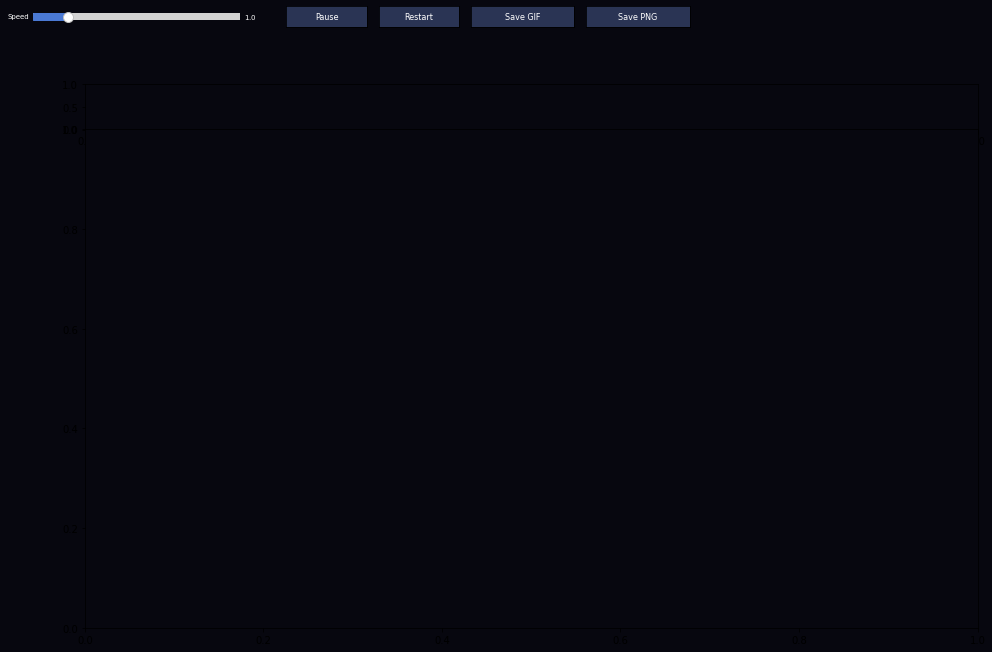

In [21]:
if __name__ == "__main__":
    main()
